In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from cmap import Colormap
cmap = Colormap("colorbrewer:dark2_8")
plt.style.use(["science", "grid"])

In [2]:
ticksize = 36
legendsize = 32
axissize = 38
titlesize = 38
lw = 2.5

METHOD_NAMES = {"deterministic": r"$\boldsymbol\delta_\theta$", "normal": r"$\boldsymbol\Sigma_\theta^{\mathrm{diag}}$",
                 "mixednormal":r"$\boldsymbol\Sigma_\theta^{\mathrm{mix}}$", "mvnormal": r"$\boldsymbol\Sigma_\theta^{\mathrm{mv}}$",
                 "sample": r"$\boldsymbol\epsilon_t^{\mathrm{ES}}$", "crps_ensemble": r"$\boldsymbol f_{\theta}^{\mathrm{S}}$"}

# Rank histograms

## UCI

In [3]:
UCI_METHODS = ["normal", "mixednormal","deterministic","sample", "crps_ensemble"]
N_BINS = 10
RESULTS_DIR = "../results/calibration"


def plot_uci_rank_histograms(dataset, methods=UCI_METHODS, n_bins=N_BINS, results_dir=RESULTS_DIR):
    """Plot normalized rank histograms for one UCI dataset, one column per method.

    Shares y-axis across methods and overlays the uniform-distribution reference
    as a dashed horizontal line.
    """
    fig, axes = plt.subplots(1, len(methods), figsize=(7 * len(methods), 3.5),
                             sharey=True, sharex=True)
    if len(methods) == 1:
        axes = [axes]

    uniform_height = 1.0 / n_bins  # density per bin under uniform on [0, n_samples]

    for ax, method in zip(axes, methods):
        path = f"{results_dir}/{dataset}__{method}__ranks.npz"
        try:
            data = np.load(path)
        except FileNotFoundError:
            ax.set_title(f"{METHOD_NAMES.get(method, method)}\n(missing)", fontsize=titlesize)
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        ranks = data["ranks"]
        n_samples = int(data["n_samples"])
        # Normalize so bar heights sum to 1 (probability per bin).
        weights = np.ones_like(ranks, dtype=float) / len(ranks)
        ax.hist(ranks, bins=n_bins, range=(0, n_samples), weights=weights, color = cmap(7),
                edgecolor="black", linewidth=1.0)
        ax.axhline(uniform_height, color="red", linestyle="--", linewidth=2.5)
        ax.set_title(METHOD_NAMES.get(method, method), fontsize=titlesize)
        ax.set_xlabel("Rank", fontsize=axissize)
        ax.tick_params(axis="both", labelsize=ticksize)
        ax.set_xlim([0,1000])

    axes[0].set_ylabel("Probability", fontsize=axissize)
    plt.savefig(f"plots/uci_rankhist_{dataset}.pdf", bbox_inches = "tight")

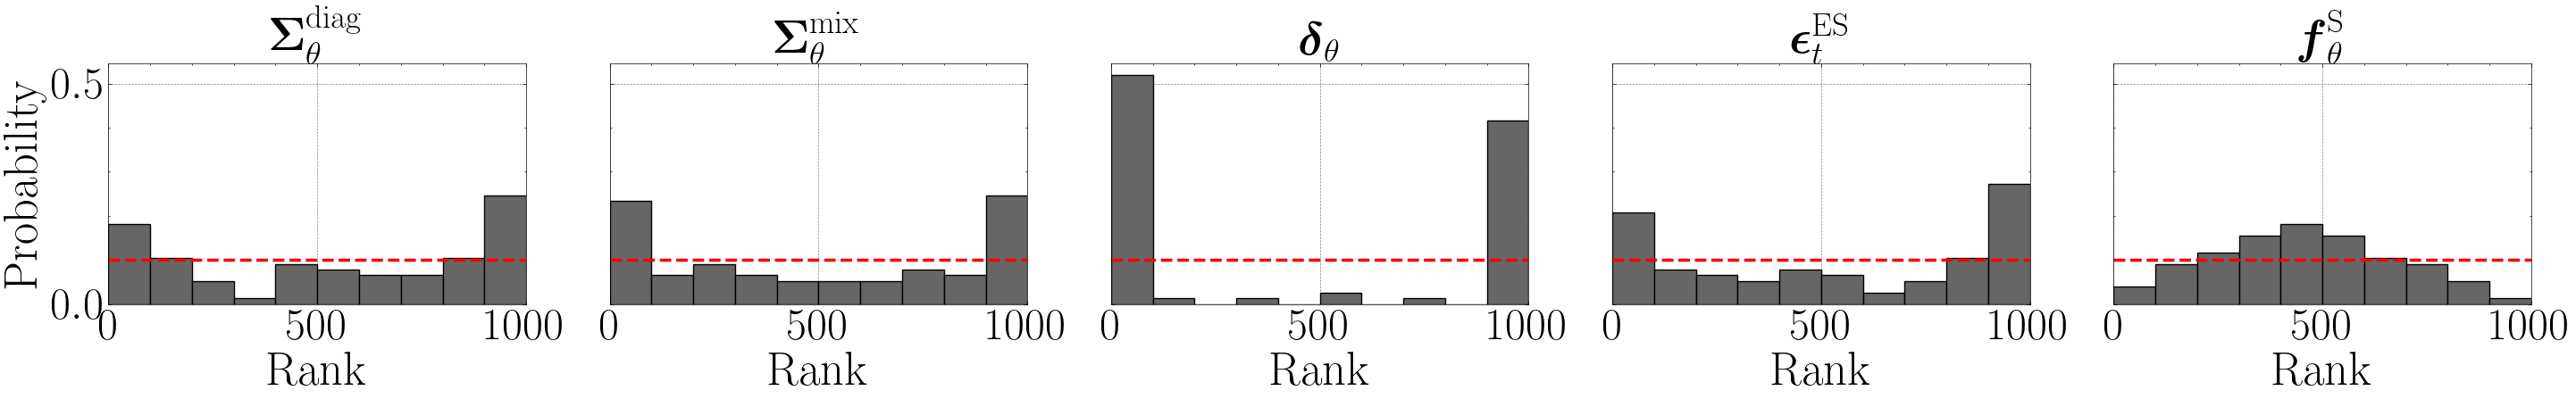

In [4]:
plot_uci_rank_histograms("energy")

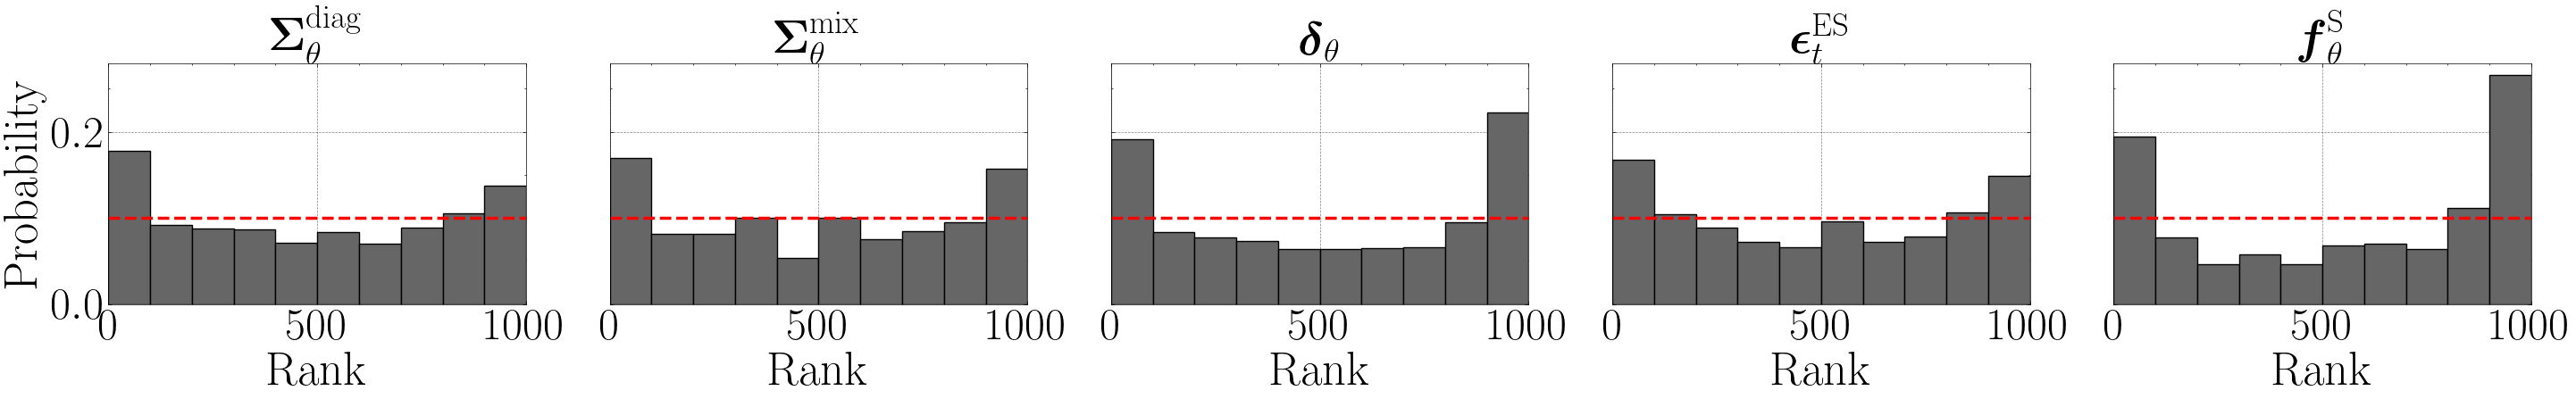

In [5]:
plot_uci_rank_histograms("kin8nm")

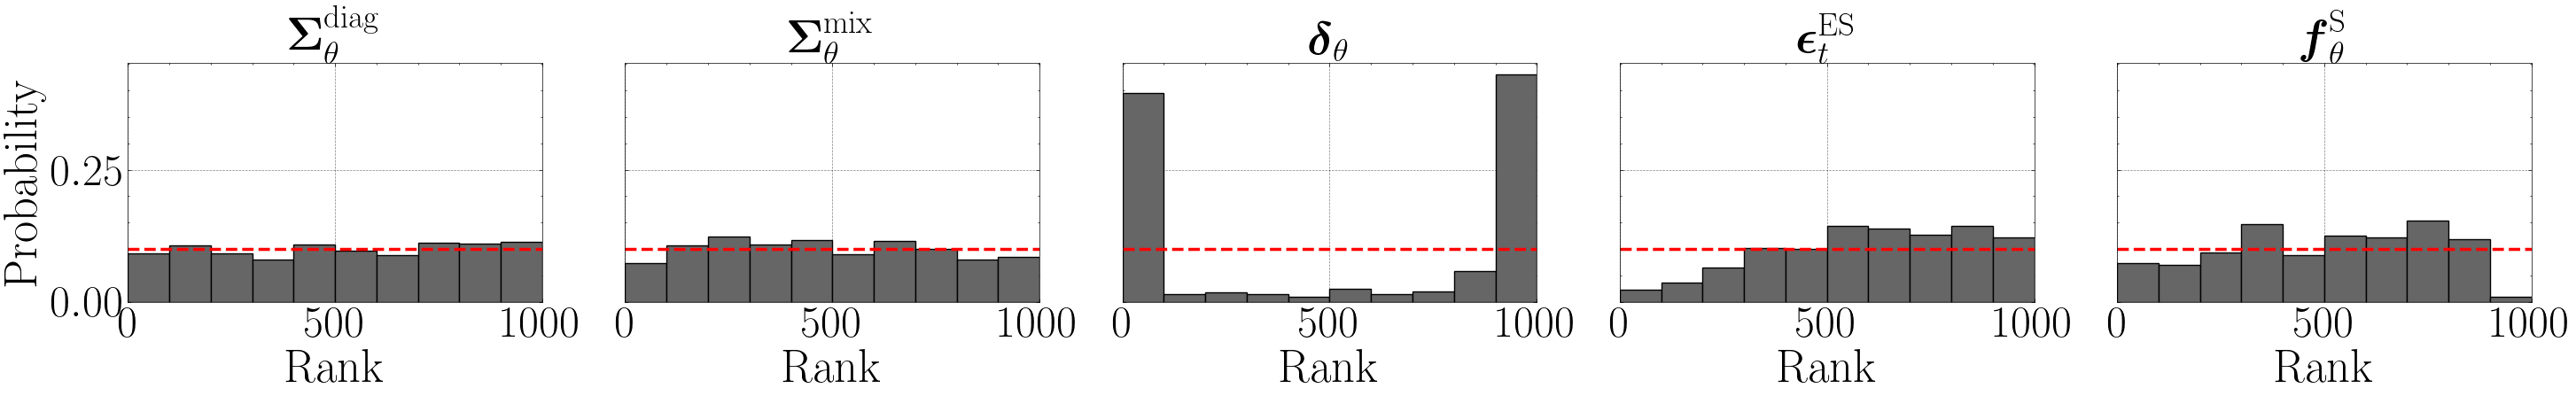

In [6]:
plot_uci_rank_histograms("naval")

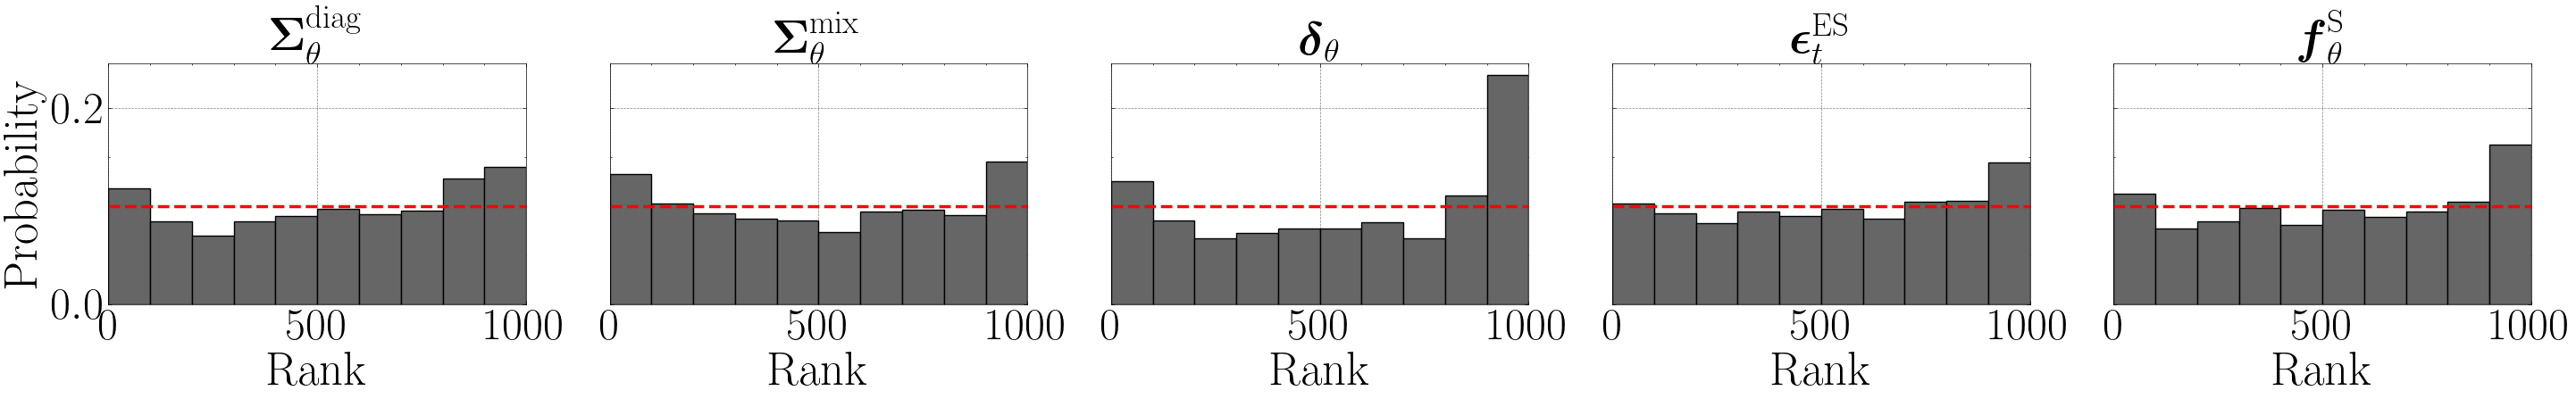

In [7]:
plot_uci_rank_histograms("power")

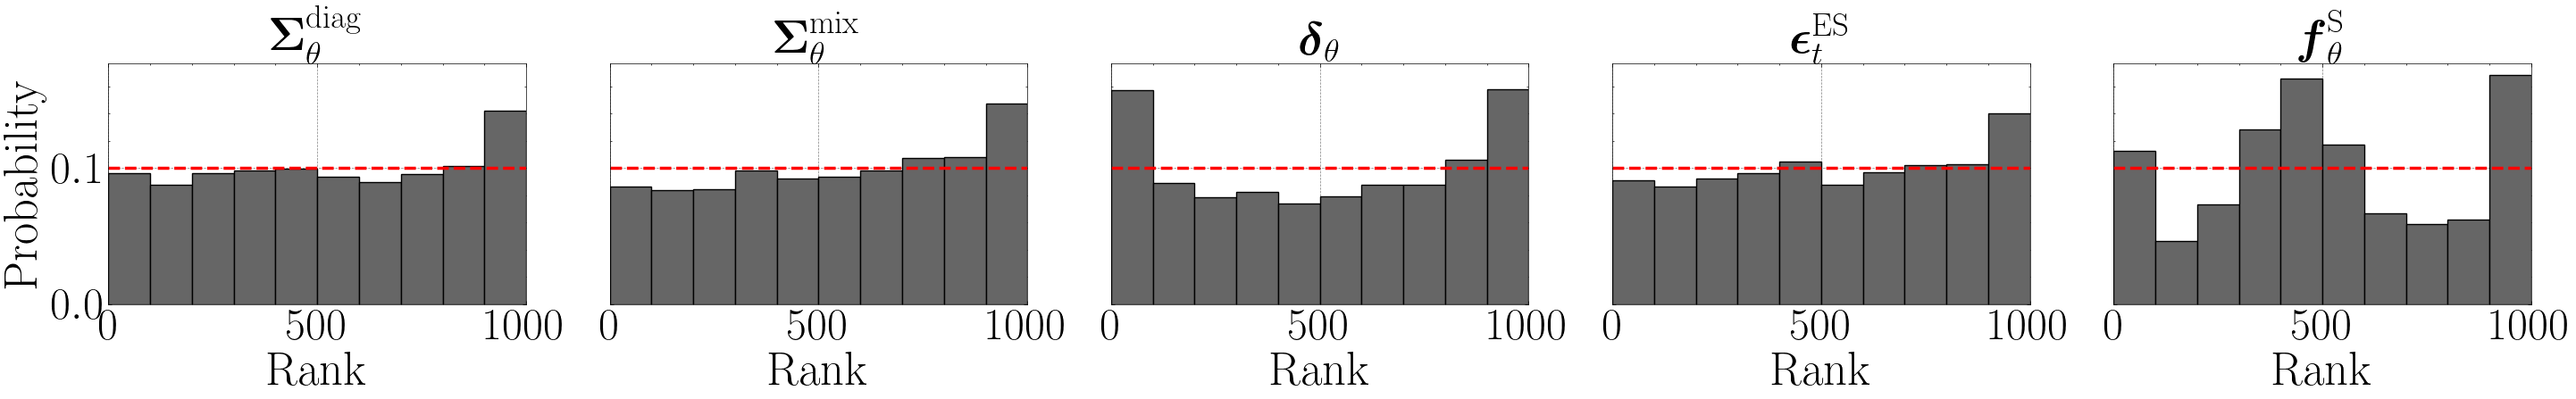

In [8]:
plot_uci_rank_histograms("protein")

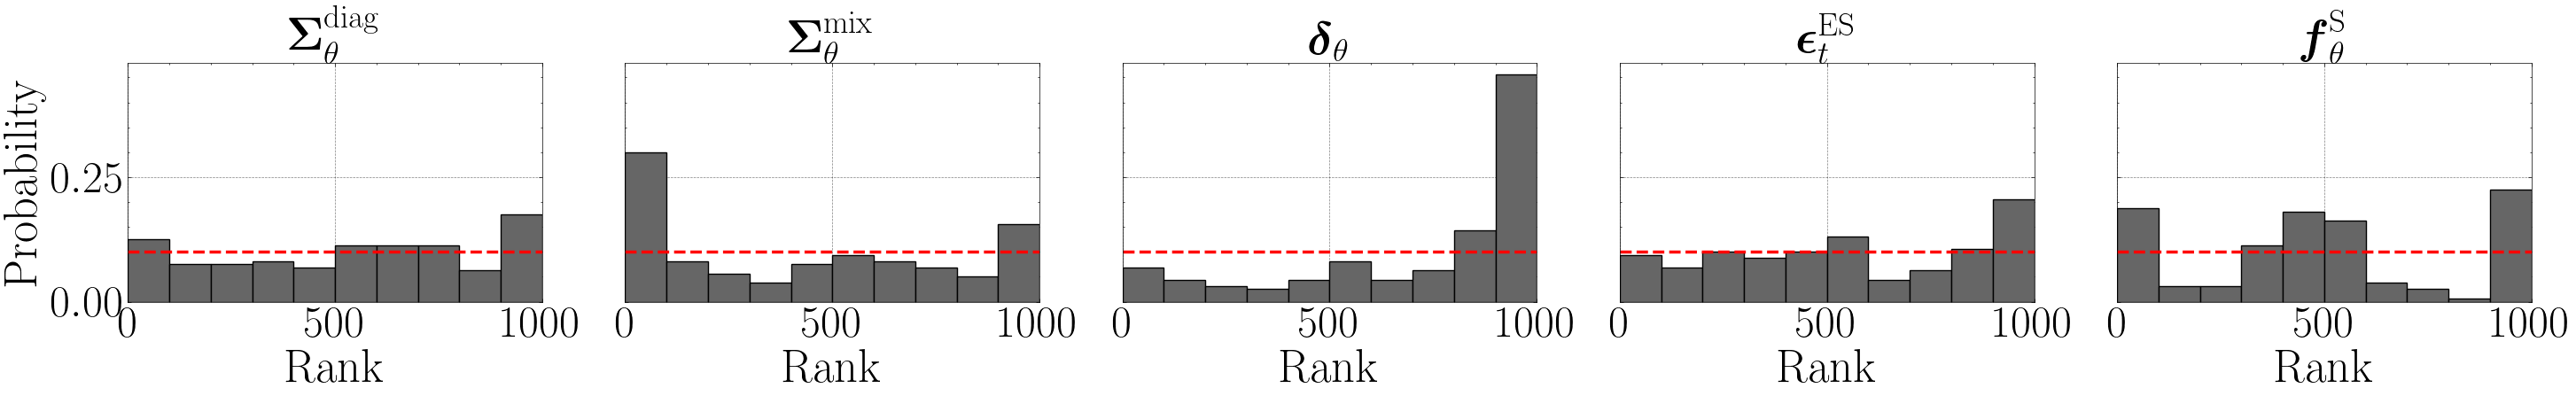

In [9]:
plot_uci_rank_histograms("wine")

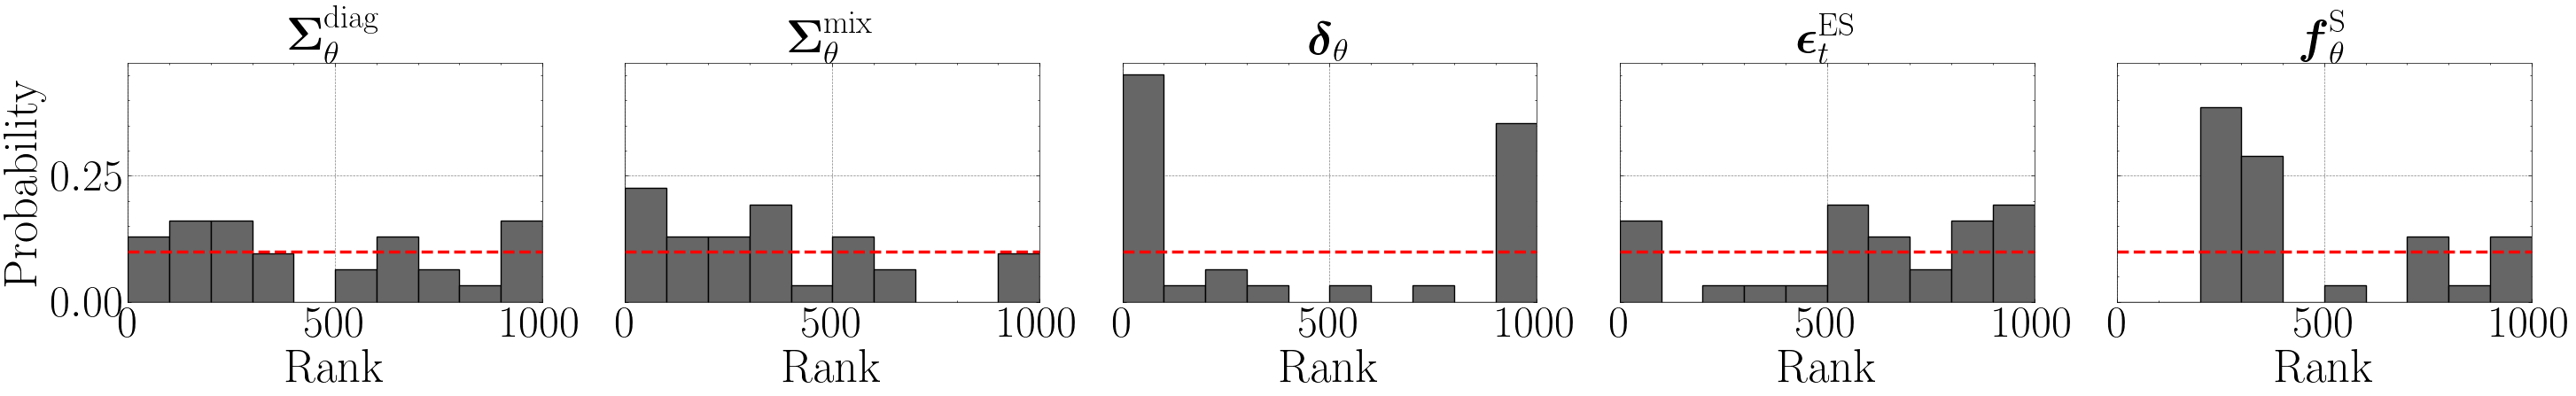

In [10]:
plot_uci_rank_histograms("yacht")

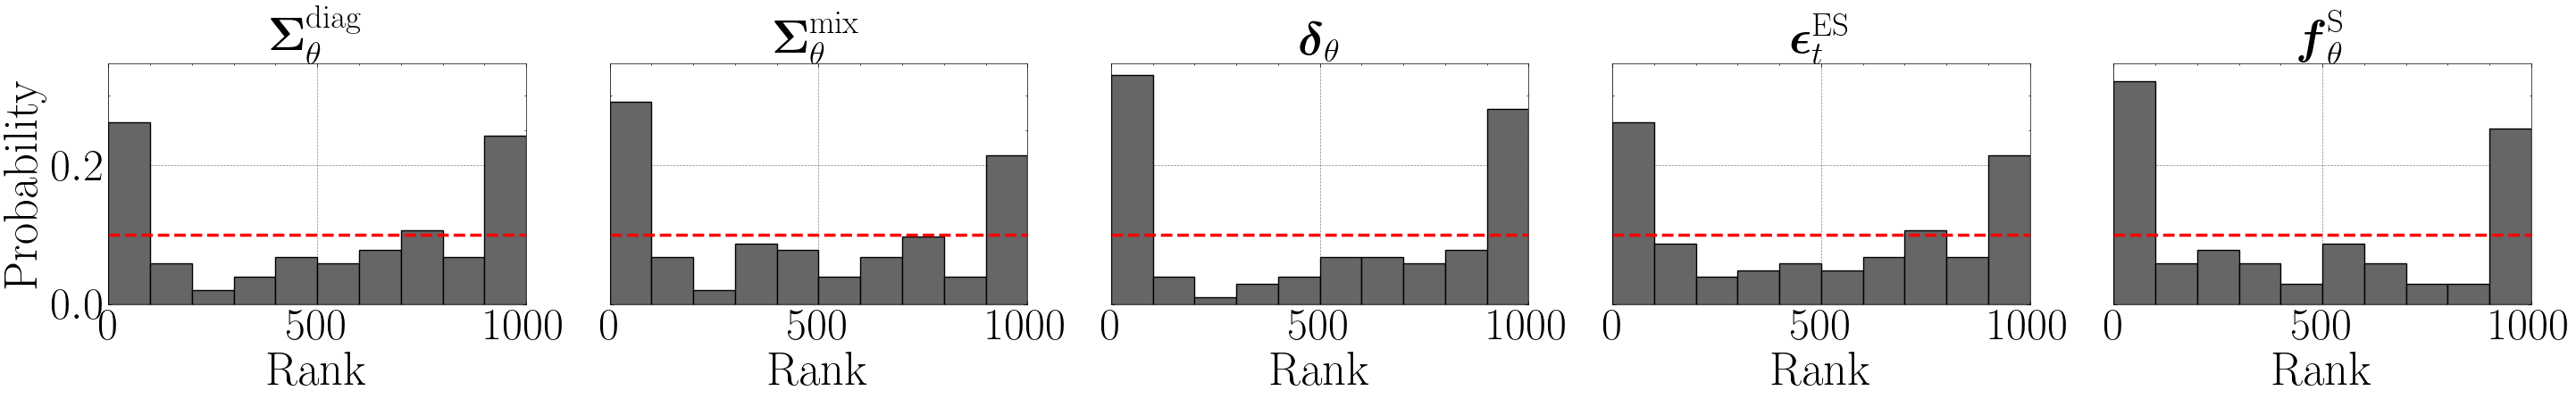

In [11]:
plot_uci_rank_histograms("concrete")

# Reliability diagram

In [12]:
ticksize = 34
legendsize = 32
axissize = 38
titlesize = 40
lw = 3.5


## UCI2

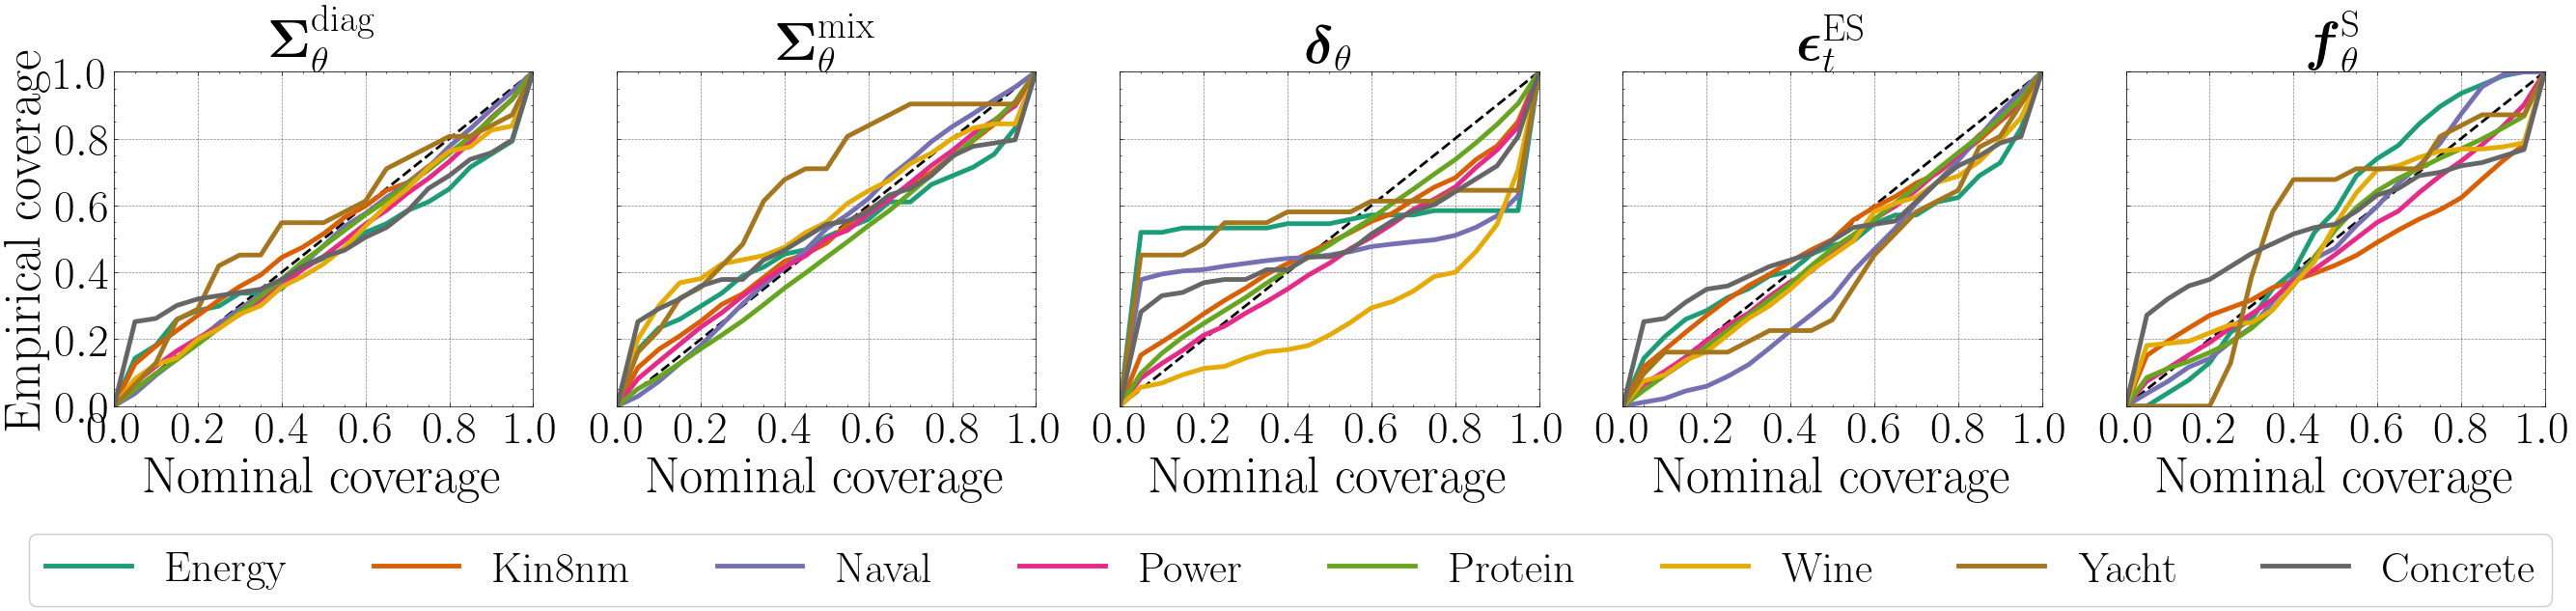

In [13]:
UCI_DATASETS = ["energy", "kin8nm", "naval", "power", "protein", "wine", "yacht", "concrete"]
UCI_METHODS = ["normal", "mixednormal","deterministic","sample", "crps_ensemble"]


def plot_uci_reliability_overlay(datasets=UCI_DATASETS, methods=UCI_METHODS, results_dir=RESULTS_DIR):
    """Overlay coverage curves of all datasets per method, one column per method."""
    fig, axes = plt.subplots(1, len(methods), figsize=(6.5 * len(methods), 4.5),
                             sharex=True, sharey=True)
    if len(methods) == 1:
        axes = [axes]

    cmap = Colormap("colorbrewer:dark2_8")
    colors = {ds: cmap(i) for i, ds in enumerate(datasets)}

    handles, labels = [], []
    for ax, method in zip(axes, methods):
        ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=2)
        for dataset in datasets:
            path = f"{results_dir}/{dataset}__{method}__coverage.npz"
            try:
                data = np.load(path)
            except FileNotFoundError:
                continue
            nominal = data["nominal_levels"]
            empirical = data["empirical_coverage"]
            label = dataset.capitalize()
            line, = ax.plot(nominal, empirical, linewidth=lw, color=colors[dataset], label=label)
            if label not in labels:
                handles.append(line)
                labels.append(label)

        ax.set_title(METHOD_NAMES.get(method, method), fontsize=titlesize)
        ax.set_xlabel("Nominal coverage", fontsize=axissize)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        #ax.set_aspect("equal")
        ax.set_xticks([0.0,0.2,0.4,0.6,0.8,1.0])
        ax.set_yticks([0.0,0.2,0.4,0.6,0.8,1.0])
        ax.tick_params(axis="both", labelsize=ticksize)
 

    axes[0].set_ylabel("Empirical coverage", fontsize=axissize)
    fig.legend(handles, labels, loc="lower center", ncol=len(labels),
               fontsize=legendsize, fancybox=True, bbox_to_anchor=(0.5, -0.4))


plot_uci_reliability_overlay()
plt.savefig("plots/uci_reliability.pdf", bbox_inches = "tight")

## PDEs

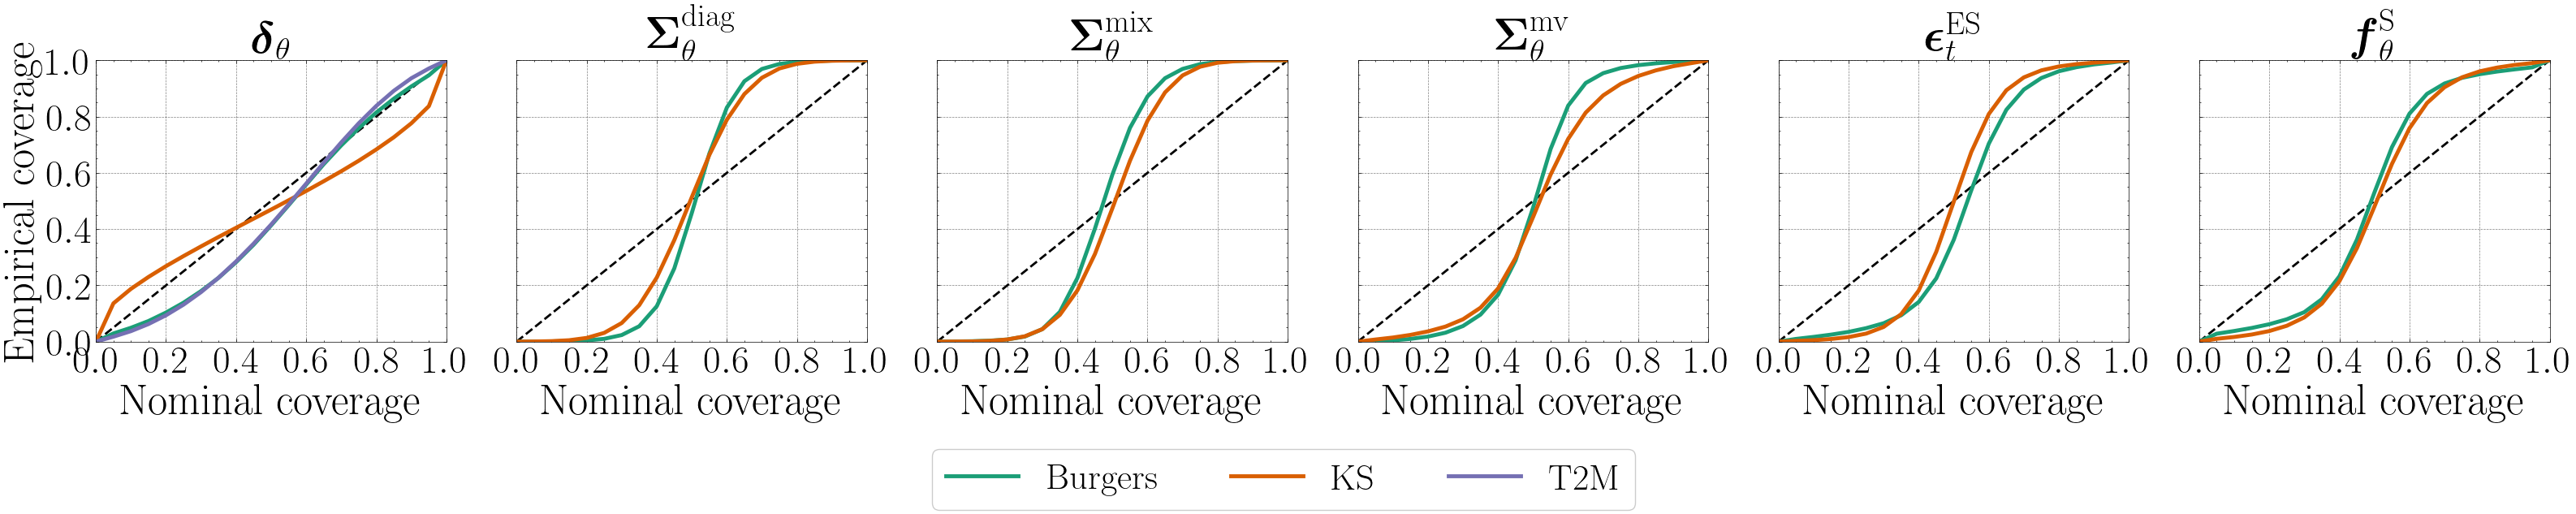

In [14]:
PDE_DATASETS = ["Burgers", "KS", "T2M"]
PDE_METHODS = ["deterministic", "normal", "mixednormal", "mvnormal", "sample", "crps_ensemble"]


def plot_pde_reliability(datasets=PDE_DATASETS, methods=PDE_METHODS, results_dir=RESULTS_DIR):
    """Overlay coverage curves of all PDE datasets per method, one column per method."""
    fig, axes = plt.subplots(1, len(methods), figsize=(6.5 * len(methods), 4.5),
                             sharex=True, sharey=True)
    if len(methods) == 1:
        axes = [axes]

    cmap = Colormap("colorbrewer:dark2_8")
    colors = {ds: cmap(i) for i, ds in enumerate(datasets)}

    handles, labels = [], []
    for ax, method in zip(axes, methods):
        ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=2)
        for dataset in datasets:
            path = f"{results_dir}/{dataset}__{method}__coverage.npz"
            try:
                data = np.load(path)
            except FileNotFoundError:
                continue
            nominal = data["nominal_levels"]
            empirical = data["empirical_coverage"]
            label = dataset
            line, = ax.plot(nominal, empirical, linewidth=lw, color=colors[dataset], label=label)
            if label not in labels:
                handles.append(line)
                labels.append(label)

        ax.set_title(METHOD_NAMES.get(method, method), fontsize=titlesize)
        ax.set_xlabel("Nominal coverage", fontsize=axissize)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.tick_params(axis="both", labelsize=ticksize)

    axes[0].set_ylabel("Empirical coverage", fontsize=axissize)
    fig.legend(handles, labels, loc="lower center", ncol=len(labels),
               fontsize=legendsize, fancybox=True, bbox_to_anchor=(0.5, -0.4))


plot_pde_reliability()
plt.savefig("plots/pde_reliability.pdf", bbox_inches="tight")